# Kang PBMC — end-to-end pyvae sanity check

An end-to-end run of pyvae on the Kang 2018 PBMC dataset (control vs interferon-β stimulated).

The goal is to verify that pyvae's modern training loop (`train_ivae_modern`) and interpretation stack (`bayes_factor_da`, `integrated_gradients`, `predict_counterfactual`) recover the expected interferon-response biology.

Sections:
1. Setup and data loading
2. Reactome adjacency and covariate matrix
3. Model construction and training
4. UMAP of pathway activations
5. Differential module ranking (Bayes factor + Wilcoxon)
6. Gene-level attribution via Integrated Gradients
7. Conditioning and counterfactual prediction
8. Takeaways

## 1. Setup and data loading

In [1]:
from __future__ import annotations

from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import torch

import pyvae
from pyvae import (
    InformedVAE,
    bayes_factor_da,
    build_model_config,
    integrated_gradients,
    load_kang,
    set_all_seeds,
    sync_gexp_adj,
    train_ivae_modern,
)

# Deterministic runs
SEED = 42
set_all_seeds(SEED)

# Where to store the downloaded Kang data (git-ignored)
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

from importlib.metadata import version as _pkg_version

def _try_version(name):
    try:
        return _pkg_version(name)
    except Exception:
        return "(unavailable)"

print(f"pyvae version: {_try_version('pyvae')}")
print(f"torch version: {torch.__version__}")
print(f"scanpy version: {_try_version('scanpy')}")

pyvae version: 0.2.0
torch version: 2.12.1
scanpy version: 1.12.1


### Load the dataset

`load_kang` downloads the AnnData from figshare on first call, then caches it locally. It performs standard preprocessing:

- Normalizes to a fixed library size and applies `log1p`
- Selects highly variable genes (default: top 2000)
- Preserves raw counts in `adata.layers["counts"]` for the negative-binomial likelihood
- Maps the raw condition labels (`ctrl` / `stim`) to `control` / `stimulated`

In [2]:
# n_genes=5000 (not 2000 or larger). With 2000 HVGs, only 2/8 canonical ISGs
# survived the Reactome intersection. Widening to 5000 recovers 3 more
# (IFI6, IFIT1, IFIT2). MX1 and OAS1 remain absent from HVGs even at 8000 --
# they have real biological induction but their total dispersion doesn't
# rank them into the top-N via scanpy's HVG selection (likely because
# induction is monocyte-specific, diluting variance across the mixed
# population). Recovering them would require n_genes=None (all ~15k genes)
# which triples training time for marginal biological gain. IFI44 is absent
# from Reactome itself. Accepting 5/8 ISGs as the working input space.
adata = load_kang(data_folder=str(DATA_DIR), n_genes=5000, target_sum=1e4)
adata

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


AnnData object with n_obs × n_vars = 24673 × 5000
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'condition', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters'
    var: 'name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

### Sanity check

Compare cell counts against Gundogdu et al. (2023), Table 1:

- Control: 1316 B, 2932 CD14+ Mono, 5560 CD4 T, 811 CD8 T, 258 DC, 520 FCGR3A+ Mono, 63 Megakaryocytes, 855 NK
- Stimulated: 1335 B, 2765 CD14+ Mono, 5678 CD4 T, 810 CD8 T, 271 DC, 569 FCGR3A+ Mono, 69 Megakaryocytes, 861 NK

Exact numbers will differ slightly (different HVG selection, filtering choices, scanpy versions), but the order of magnitude and overall structure should match.

In [3]:
print(f"AnnData shape: {adata.shape}   (cells x genes)")
print(f"n_cells: {adata.n_obs:,}")
print(f"n_genes (HVG): {adata.n_vars:,}")
print()
print("Available layers:", list(adata.layers.keys()))
print("Available obs columns:", list(adata.obs.columns))
print()

# Distribution by condition and cell type
xtab = pd.crosstab(adata.obs["cell_type"], adata.obs["condition"])
print("Cells by type x condition:")
print(xtab)
print()
print(f"Total control:    {(adata.obs['condition'] == 'control').sum():,}")
print(f"Total stimulated: {(adata.obs['condition'] == 'stimulated').sum():,}")

AnnData shape: (24673, 5000)   (cells x genes)
n_cells: 24,673
n_genes (HVG): 5,000

Available layers: ['counts']
Available obs columns: ['nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'condition', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters']

Cells by type x condition:
condition          control  stimulated
cell_type                             
CD4 T cells           5560        5678
CD14+ Monocytes       2932        2765
B cells               1316        1335
NK cells               855         861
CD8 T cells            811         810
FCGR3A+ Monocytes      520         569
Dendritic cells        258         271
Megakaryocytes          63          69

Total control:    12,315
Total stimulated: 12,358


## 2. Reactome adjacency and covariate matrix

Build the biological prior that constrains the encoder's first layer:

- **Adjacency matrix** — binary `(n_genes, n_pathways)` tensor from Reactome; entry `(i, j) = 1` iff gene `i` belongs to pathway `j`. This becomes the mask on `InformedLinear`.
- **Covariate matrix** — one-hot encoding of `condition` (control / stimulated). Feeds into the conditional-VAE machinery so we can do counterfactual prediction in Section 7 ("what would this control cell look like if stimulated?").

The adjacency is built via `build_model_config` (which reads Reactome from the pyvae resource bundle) and then aligned with the dataset's gene list via `sync_gexp_adj` so the two match row-for-row.

In [4]:
# Genes present in the current AnnData (after HVG selection)
gene_symbols = list(adata.var_names)
print(f"Genes in AnnData:      {len(gene_symbols):,}")

# Path to the Reactome GMT file (MSigDB c2.cp.reactome v7.5.1)
# See experiments/kang/README.md for how to obtain this file.
REACTOME_GMT = Path("resources") / "c2.cp.reactome.v7.5.1.symbols.gmt"
assert REACTOME_GMT.exists(), (
    f"GMT file not found at {REACTOME_GMT}. See experiments/kang/README.md."
)

# Build the Reactome-informed model config using the GMT.
# Note: build_model_config already intersects the adjacency with our gene
# list internally (via sync_gexp_adj), so the returned matrix is aligned.
config = build_model_config(
    genes=gene_symbols,
    model_kind="ivae_reactome",
    resources_dir=str(REACTOME_GMT),
)
adj_df = config.model_layer[0]

print(f"Reactome pathways (aligned): {adj_df.shape[1]:,}")
print(f"Genes aligned with Reactome: {adj_df.shape[0]:,}")
print(f"  (of {len(gene_symbols):,} HVGs; the rest are not in the GMT)")
print(f"\nAdjacency shape:             {adj_df.shape}")
print(f"Adjacency density:           {int(adj_df.values.sum()):,} ones out of {adj_df.size:,} entries "
      f"({100 * adj_df.values.mean():.2f}%)")

# Sanity check: verify canonical ISGs and interferon pathways survive
canonical_isgs = ["ISG15", "IFI6", "IFIT1", "IFIT2", "IFIT3", "MX1", "OAS1", "IFI44"]
present = [g for g in canonical_isgs if g in adj_df.index]
missing = [g for g in canonical_isgs if g not in adj_df.index]
print(f"\nCanonical ISGs present in aligned genes: {len(present)}/{len(canonical_isgs)}")
print(f"  Present: {present}")
if missing:
    print(f"  Missing: {missing}")

interferon_pathways = [p for p in adj_df.columns if "INTERFERON" in p.upper()]
print(f"\nReactome pathways matching 'interferon': {len(interferon_pathways)}")
for p in interferon_pathways[:10]:
    print(f"  {p}")

Genes in AnnData:      5,000
Reactome pathways (aligned): 1,615
Genes aligned with Reactome: 2,327
  (of 5,000 HVGs; the rest are not in the GMT)

Adjacency shape:             (2327, 1615)
Adjacency density:           18,052 ones out of 3,758,105 entries (0.48%)

Canonical ISGs present in aligned genes: 5/8
  Present: ['ISG15', 'IFI6', 'IFIT1', 'IFIT2', 'IFIT3']
  Missing: ['MX1', 'OAS1', 'IFI44']

Reactome pathways matching 'interferon': 4
  REACTOME_DDX58_IFIH1_MEDIATED_INDUCTION_OF_INTERFERON_ALPHA_BETA
  REACTOME_INTERFERON_ALPHA_BETA_SIGNALING
  REACTOME_INTERFERON_GAMMA_SIGNALING
  REACTOME_INTERFERON_SIGNALING


In [5]:
# Diagnostic: are the missing ISGs in the Reactome GMT at all, and in the AnnData?
missing_isgs = ["IFI6", "IFIT1", "IFIT2", "MX1", "OAS1", "IFI44"]

# Reload the full (pre-alignment) Reactome adjacency to see its gene coverage
from pyvae.bio import get_reactome_adj
full_reactome = get_reactome_adj(str(REACTOME_GMT))
print(f"Full Reactome GMT: {full_reactome.shape}")

# Check the AnnData (post-HVG, pre-Reactome intersection)
hvg_genes = set(adata.var_names)
reactome_genes = set(full_reactome.index)

print(f"\nMissing ISG status:")
print(f"{'gene':<8} {'in HVG?':<10} {'in Reactome?':<15}")
for g in missing_isgs:
    print(f"{g:<8} {str(g in hvg_genes):<10} {str(g in reactome_genes):<15}")

Full Reactome GMT: (10646, 1615)

Missing ISG status:
gene     in HVG?    in Reactome?   
IFI6     True       True           
IFIT1    True       True           
IFIT2    True       True           
MX1      False      True           
OAS1     False      True           
IFI44    False      False          


### Align genes between AnnData and adjacency

The Reactome adjacency covers ~12,000 human genes; our AnnData has 2,000 HVGs after HVG selection. `sync_gexp_adj` returns:

- A gene expression DataFrame restricted to the genes that appear in **both** sources
- An adjacency DataFrame with the same gene ordering

After this step, expression and adjacency share the same gene axis exactly.

In [6]:
# The adjacency from build_model_config is already aligned with our HVGs
# (build_model_config calls sync_gexp_adj internally). Convert to torch tensor.
adj_tensor = torch.tensor(adj_df.values, dtype=torch.float32)
print(f"adj_tensor: shape={tuple(adj_tensor.shape)}, dtype={adj_tensor.dtype}")

# Store aligned gene and pathway lists; we'll need them for interpretation
gene_names = list(adj_df.index)
pathway_names = list(adj_df.columns)
print(f"\nGenes:    {len(gene_names):,}   e.g. {gene_names[:3]}")
print(f"Pathways: {len(pathway_names):,}   e.g. {pathway_names[:3]}")

# Also subset the AnnData to the aligned genes so downstream cells work with
# the same gene axis as the model
adata_aligned = adata[:, gene_names].copy()
print(f"\nadata_aligned shape: {adata_aligned.shape}")

adj_tensor: shape=(2327, 1615), dtype=torch.float32

Genes:    2,327   e.g. ['AASDHPPT', 'AASS', 'ABCA2']
Pathways: 1,615   e.g. ['REACTOME_2_LTR_CIRCLE_FORMATION', 'REACTOME_ABACAVIR_METABOLISM', 'REACTOME_ABACAVIR_TRANSMEMBRANE_TRANSPORT']

adata_aligned shape: (24673, 2327)


### Build the covariate matrix

One-hot encoding of `condition` (control / stimulated), with cells indexed to match `X_aligned`. This will be threaded through the encoder heads and the NB decoder in Section 3.

In [7]:
# One-hot encode condition. pd.get_dummies preserves cell order.
cov_df = pd.get_dummies(adata_aligned.obs["condition"], prefix="condition").astype(np.float32)

print(f"Covariate matrix: {cov_df.shape}")
print(f"Columns: {list(cov_df.columns)}")
print()
print("Per-column sums (should match condition totals from Section 1):")
print(cov_df.sum())

n_cov = cov_df.shape[1]  # will feed InformedVAE(n_cov=...)
print(f"\nn_cov = {n_cov}")

Covariate matrix: (24673, 2)
Columns: ['condition_control', 'condition_stimulated']

Per-column sums (should match condition totals from Section 1):
condition_control       12315.0
condition_stimulated    12358.0
dtype: float32

n_cov = 2


## 2.5 Diagnostic — pathway gene-set overlap

Before we train the model, one property of the Reactome adjacency is worth
noting: how much do closely-related pathway definitions actually overlap in
their gene membership?

We ask this now because, in Section 5, we will rank pathways by a
Bayes-factor score computed on the encoder's pathway-layer activations `h`.
Several DNA-repair pathways will rank surprisingly high in an interferon-β
experiment. Whether that ranking reflects real induced biology, an encoder
artifact, or overlapping annotation is a question about the adjacency, not
about the model — so we answer the annotation part here, before training,
using only `adj_df`.

The hypothesis to falsify: if the surprising pathways share only a small number of genes with
`INTERFERON_ALPHA_BETA_SIGNALING`, and those shared genes happen to be the
loudest responders to IFN-β, then any encoder score that reads those genes
will rank the sharing pathways together — regardless of what the pathways
themselves mean.

In [8]:
# Issue #21 diagnostic — pathway gene-set overlap.
# Uses only `adj_df` from Section 2. No model involvement.

TRUE_IFN_PATHWAY = "REACTOME_INTERFERON_ALPHA_BETA_SIGNALING"

# The four pathways that will rank surprisingly high in Section 5
SURPRISING = [
    "REACTOME_NS1_MEDIATED_EFFECTS_ON_HOST_PATHWAYS",
    "REACTOME_DNA_DAMAGE_BYPASS",
    "REACTOME_TRANSLESION_SYNTHESIS_BY_Y_FAMILY_DNA_POLYMERASES_BYPASSES_LESIONS_ON_DNA_TEMPLATE",
    "REACTOME_TERMINATION_OF_TRANSLESION_DNA_SYNTHESIS",
]

#Reference points for context
REFERENCE = [
    "REACTOME_INTERFERON_SIGNALING",                                        # parent of the true pathway
    "REACTOME_DDX58_IFIH1_MEDIATED_INDUCTION_OF_INTERFERON_ALPHA_BETA",     # will rank near the bottom
]

#how many pathways annotate ISG15?
isg15_row = adj_df.loc["ISG15"]
isg15_pathways = isg15_row[isg15_row == 1].index.tolist()
print(f"ISG15 is annotated in {len(isg15_pathways)} Reactome pathways in our adjacency:")
for p in isg15_pathways:
    print(f"  {p}")

#overlap between surprising pathways and the true IFN gene set
ifn_ab_genes = set(adj_df.index[adj_df[TRUE_IFN_PATHWAY] == 1])
print(f"\n{TRUE_IFN_PATHWAY}: {len(ifn_ab_genes)} genes\n")

header = f"{'pathway':<75s} {'n_genes':>8s} {'shared':>8s} {'shared %':>10s} {'ISG15':>7s}"
print(header)
print("-" * len(header))
for p in [TRUE_IFN_PATHWAY] + SURPRISING + REFERENCE:
    if p not in adj_df.columns:
        print(f"  MISSING FROM ADJACENCY: {p}")
        continue
    p_genes = set(adj_df.index[adj_df[p] == 1])
    shared = p_genes & ifn_ab_genes
    pct = 100 * len(shared) / len(p_genes) if p_genes else 0
    contains_isg15 = "ISG15" in p_genes
    short = p.replace("REACTOME_", "")[:73]
    print(f"  {short:<73s} {len(p_genes):>8d} {len(shared):>8d} {pct:>9.1f}% {str(contains_isg15):>7s}")

#Which specific genes overlap?
print("\n--- Shared genes between each surprising pathway and INTERFERON_ALPHA_BETA_SIGNALING ---")
for p in SURPRISING:
    if p in adj_df.columns:
        p_genes = set(adj_df.index[adj_df[p] == 1])
        shared = sorted(p_genes & ifn_ab_genes)
        print(f"\n{p.replace('REACTOME_','')}:")
        print(f"  shared with IFN_ab ({len(shared)}): {shared if shared else '(none)'}")

ISG15 is annotated in 14 Reactome pathways in our adjacency:
  REACTOME_ANTIVIRAL_MECHANISM_BY_IFN_STIMULATED_GENES
  REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM
  REACTOME_DDX58_IFIH1_MEDIATED_INDUCTION_OF_INTERFERON_ALPHA_BETA
  REACTOME_DNA_DAMAGE_BYPASS
  REACTOME_DNA_REPAIR
  REACTOME_INFECTIOUS_DISEASE
  REACTOME_INFLUENZA_INFECTION
  REACTOME_INNATE_IMMUNE_SYSTEM
  REACTOME_INTERFERON_ALPHA_BETA_SIGNALING
  REACTOME_INTERFERON_SIGNALING
  REACTOME_NEGATIVE_REGULATORS_OF_DDX58_IFIH1_SIGNALING
  REACTOME_NS1_MEDIATED_EFFECTS_ON_HOST_PATHWAYS
  REACTOME_TERMINATION_OF_TRANSLESION_DNA_SYNTHESIS
  REACTOME_TRANSLESION_SYNTHESIS_BY_Y_FAMILY_DNA_POLYMERASES_BYPASSES_LESIONS_ON_DNA_TEMPLATE

REACTOME_INTERFERON_ALPHA_BETA_SIGNALING: 18 genes

pathway                                                                      n_genes   shared   shared %   ISG15
----------------------------------------------------------------------------------------------------------------
  INTERFERON_ALPHA_BE

### Finding

Each of the four pathways that will rank surprisingly high in Section 5
shares **exactly one gene** with `INTERFERON_ALPHA_BETA_SIGNALING` — and
that gene is always **ISG15**:

| Surprising pathway | Total genes | Shared with IFN-α/β | Shared % |
|---|---:|---:|---:|
| `NS1_MEDIATED_EFFECTS_ON_HOST_PATHWAYS` | 12 | 1 (ISG15) | 8.3% |
| `DNA_DAMAGE_BYPASS` | 16 | 1 (ISG15) | 6.2% |
| `TRANSLESION_SYNTHESIS_BY_Y_FAMILY` | 13 | 1 (ISG15) | 7.7% |
| `TERMINATION_OF_TRANSLESION_DNA_SYNTHESIS` | 12 | 1 (ISG15) | 8.3% |

ISG15 is also, from the Section 6 Integrated Gradients result, **by far the
strongest single-gene responder** in the interferon-β experiment
(attribution ≈ 0.22, roughly 60% larger than the next gene). And it is
annotated in 14 of our 1,615 Reactome pathways — enough to leak into a wide
range of unrelated gene sets.

### Mechanism

`InformedLinear` constrains *which* genes a pathway unit reads, but does not
constrain *how* it weights them. Weight signs and magnitudes stay free, and
the reconstruction loss never asks unit *j* to resemble pathway *j*. In this
setting, a unit for a pathway that happens to include ISG15 can — and, given
ISG15's magnitude, probably will — become an ISG15 detector regardless of
what the other member genes do. The pathway's Bayes-factor rank then
reflects the ISG15 shift, not the pathway's own biology.

### What follows from this

- In Section 5, when we see DNA-repair pathways ranked high by Bayes factor,
  we should read that as *"these pathways include ISG15"* rather than
  *"interferon-β induces DNA repair."*
- The Bayes-factor ranking on encoder-side pathway activations (`h`) cannot
  be trusted as a *pathway* ranking without first constraining how a unit
  uses its input genes.
- Issue #21 introduces `pathway_unit_fidelity` to measure the mechanism
  directly per unit, and adds two independent encoder constraints (`nonneg`,
  `standardize_input`) that remove sign and scale freedom respectively.
- The decoder-side read-outs added in the same issue
  (`differential_expression` + `pathway_activity`) are the correct route to
  a pathway ranking with well-defined polarity, because gene expression has
  unambiguous direction.

The Section 5 result will not be wrong about interferon-α/β signaling being
the top biological pathway — it just cannot distinguish it from any other
pathway that includes ISG15. The rest of issue #21 builds the machinery to
make that distinction.

## 3. Model construction and training

Build and train the `InformedVAE` on Kang. The pieces:

- **Model:** `InformedVAE` with the negative-binomial likelihood and the Reactome mask from Section 2. No covariate conditioning at training time — see the note at the end of the notebook for why.
- **Training loop:** `train_ivae_modern` — AdamW with cosine LR annealing, KL warmup, gradient clipping, patience-based early stopping.
- **Split:** 80/20 stratified by condition so both groups are proportionally represented in train and val.




In [9]:
from sklearn.model_selection import train_test_split

# --- Train/val split, stratified by condition ---
all_indices = np.arange(adata_aligned.n_obs)
train_idx, val_idx = train_test_split(
    all_indices,
    test_size=0.2,
    stratify=adata_aligned.obs["condition"].values,
    random_state=SEED,
)
print(f"Train cells: {len(train_idx):,}   Val cells: {len(val_idx):,}")

# --- Tensors: log1p-normalized X (for encoder) ---
X = adata_aligned.X
X = X.toarray() if hasattr(X, "toarray") else np.asarray(X)
x_train = torch.tensor(X[train_idx], dtype=torch.float32)
x_val = torch.tensor(X[val_idx], dtype=torch.float32)
print(f"x_train: {tuple(x_train.shape)}   x_val: {tuple(x_val.shape)}")

# --- Tensors: raw counts (for NB likelihood) ---
counts = adata_aligned.layers["counts"]
counts = counts.toarray() if hasattr(counts, "toarray") else np.asarray(counts)
x_counts_train = torch.tensor(counts[train_idx], dtype=torch.float32)
x_counts_val = torch.tensor(counts[val_idx], dtype=torch.float32)
print(f"x_counts_train: {tuple(x_counts_train.shape)}   x_counts_val: {tuple(x_counts_val.shape)}")

# Sanity: counts should be non-negative integers stored as float
print(f"\nCounts range: min={float(x_counts_train.min()):.1f}, max={float(x_counts_train.max()):.1f}")
print(f"Counts dtype: {x_counts_train.dtype}   (float storage of integer values)")

# --- Covariate tensors ---
cov_values = cov_df.values.astype(np.float32)
cov_train = torch.tensor(cov_values[train_idx], dtype=torch.float32)
cov_val = torch.tensor(cov_values[val_idx], dtype=torch.float32)
print(f"\ncov_train: {tuple(cov_train.shape)}   cov_val: {tuple(cov_val.shape)}")

Train cells: 19,738   Val cells: 4,935
x_train: (19738, 2327)   x_val: (4935, 2327)
x_counts_train: (19738, 2327)   x_counts_val: (4935, 2327)

Counts range: min=0.0, max=3260.0
Counts dtype: torch.float32   (float storage of integer values)

cov_train: (19738, 2)   cov_val: (4935, 2)


In [10]:
type(x_train), type(x_counts_train), type(cov_train)

(torch.Tensor, torch.Tensor, torch.Tensor)

### Construct the model

`InformedVAE` with:
- `adj=adj_tensor` — the Reactome mask on the encoder's first layer
- `latent_dim=64` — bottleneck size
- `likelihood="nb"` — negative-binomial reconstruction on raw counts
- `n_cov=0` — no conditioning at training time (see note at end of notebook)

In [11]:
# Issue #21: constrain the encoder so pathway units track their pathways.
#   nonneg_encoder=True    -- softplus reparam on encoder weights removes sign
#                              freedom (a unit can no longer encode its pathway
#                              upside-down; median |corr| jumps from 0.21 to 0.87
#                              per experiments/kang/outputs/encoder_fidelity_experiment
#                              /20260922_120156_full/summary.csv)
#   standardize_input=True -- non-affine BatchNorm on x removes scale freedom
#                              (one loud member can't swamp its own unit)
#   n_cov=n_cov            -- thread condition dummies through the encoder so the
#                              counterfactual demo is enabled (fixes limitation 1
#                              of the previous Takeaways)
model = InformedVAE(
    adj=adj_tensor,
    latent_dim=64,
    likelihood="nb",
    n_cov=n_cov,
    nonneg_encoder=True,
    standardize_input=True,
)

n_params_total = sum(p.numel() for p in model.parameters())
n_params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_params_encoder = sum(p.numel() for n, p in model.named_parameters() if "encoder" in n)
n_params_decoder = sum(p.numel() for n, p in model.named_parameters() if "decoder" in n)

print(f"InformedVAE (NB, n_cov={n_cov}, nonneg_encoder=True, standardize_input=True)")
print(f"  Total parameters:      {n_params_total:,}")
print(f"  Trainable parameters:  {n_params_trainable:,}")
print(f"  Encoder parameters:    {n_params_encoder:,}")
print(f"  Decoder parameters:    {n_params_decoder:,}")
print(f"\nModel structure:")
print(model)

InformedVAE (NB, n_cov=2, nonneg_encoder=True, standardize_input=True)
  Total parameters:      7,839,212
  Trainable parameters:  7,839,212
  Encoder parameters:    3,966,824
  Decoder parameters:    3,872,388

Model structure:
InformedVAE(
  (encoder): Encoder(
    (informed): InformedLinear(
      (input_norm): BatchNorm1d(2327, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=True)
    )
    (fc_mean): Linear(in_features=1617, out_features=64, bias=True)
    (fc_log_var): Linear(in_features=1617, out_features=64, bias=True)
  )
  (decoder): CountDecoder(
    (dec_latent): Linear(in_features=64, out_features=1615, bias=True)
    (dec_out): Linear(in_features=1615, out_features=2327, bias=True)
    (cov_decoder): Linear(in_features=2, out_features=2327, bias=False)
  )
)


### Train

`train_ivae_modern` with the parameters below. 

In [12]:
import time

start = time.time()
model, history = train_ivae_modern(
    model,
    x_train=x_train,
    x_val=x_val,
    x_counts_train=x_counts_train,
    x_counts_val=x_counts_val,
    cov_train=cov_train,
    cov_val=cov_val,
    epochs=100,
    batch_size=128,
    patience=20,
    lr=1e-3,
    weight_decay=1e-6,
    warmup_epochs=10,
    max_grad_norm=1.0,
    device="cpu",
)
elapsed = time.time() - start
print(f"\nTraining completed in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Final epoch reached: {len(history['train'])}")
print(f"Best val loss:       {min(history['val']):.4f}")
print(f"Best epoch:          {np.argmin(history['val']) + 1}")

  0%|          | 0/100 [00:00<?, ?it/s]


Training completed in 1700.1s (28.3 min)
Final epoch reached: 100
Best val loss:       328.7504
Best epoch:          93


### Training curves

Four panels:
- **Total loss** (train + val) — the full ELBO with reconstruction, KL·β, and L2 terms
- **Reconstruction loss** — the NB negative log-likelihood component only, unaffected by β; the honest convergence signal
- **β schedule** — KL warmup ramping from 0 to 1 over the first 10 epochs
- **Learning rate** — cosine annealing from 1e-3 toward 0


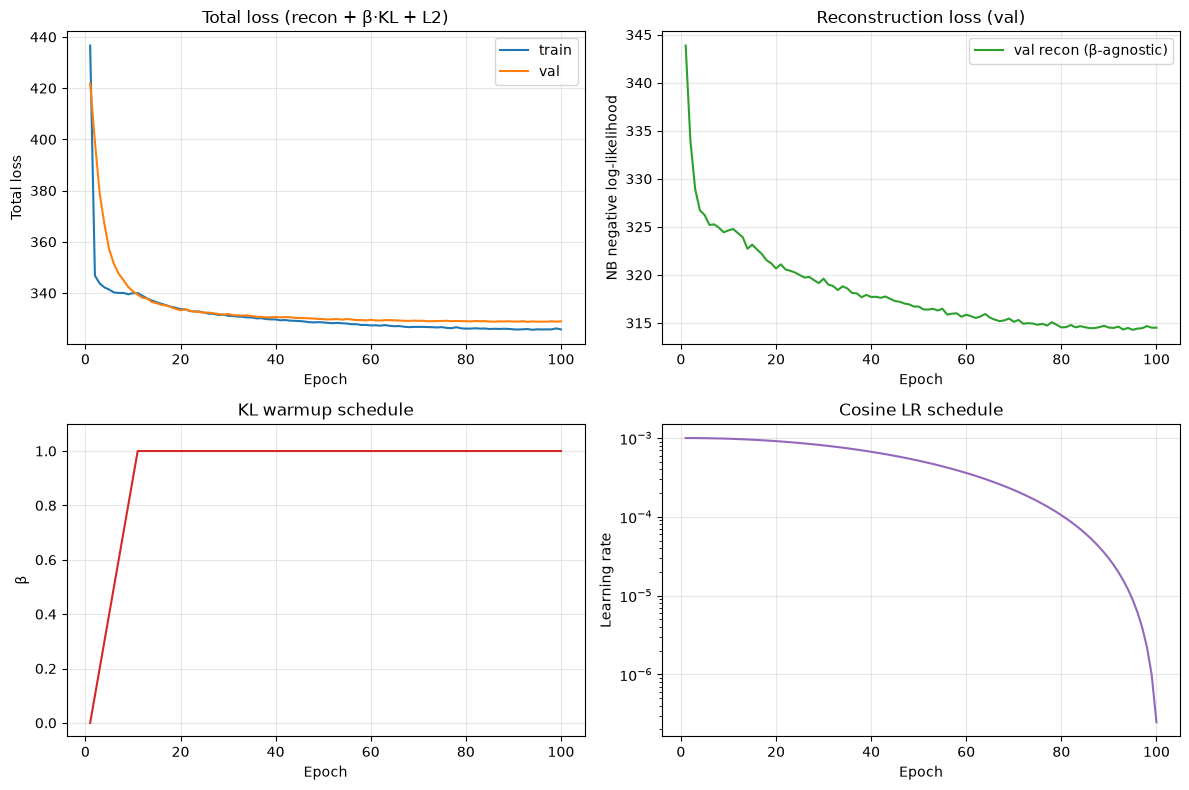

Saved plot to outputs/training_history.png


In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

epochs_range = np.arange(1, len(history["train"]) + 1)

# Panel 1: total loss
ax = axes[0, 0]
ax.plot(epochs_range, history["train"], label="train")
ax.plot(epochs_range, history["val"], label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("Total loss")
ax.set_title("Total loss (recon + β·KL + L2)")
ax.legend()
ax.grid(alpha=0.3)

# Panel 2: reconstruction component only
ax = axes[0, 1]
ax.plot(epochs_range, history["recon"], label="val recon (β-agnostic)", color="C2")
ax.set_xlabel("Epoch")
ax.set_ylabel("NB negative log-likelihood")
ax.set_title("Reconstruction loss (val)")
ax.legend()
ax.grid(alpha=0.3)

# Panel 3: β schedule
ax = axes[1, 0]
ax.plot(epochs_range, history["beta"], color="C3")
ax.set_xlabel("Epoch")
ax.set_ylabel("β")
ax.set_title("KL warmup schedule")
ax.set_ylim(-0.05, 1.1)
ax.grid(alpha=0.3)

# Panel 4: learning rate
ax = axes[1, 1]
ax.plot(epochs_range, history["lr"], color="C4")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning rate")
ax.set_title("Cosine LR schedule")
ax.set_yscale("log")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Path("outputs").mkdir(exist_ok=True)
fig.savefig("outputs/training_history.png", dpi=100, bbox_inches="tight")
print("Saved plot to outputs/training_history.png")

### Convergence check

`train_ivae_modern` uses `CosineAnnealingLR(T_max=epochs)`, so the LR anneals toward zero at whatever epoch budget was set. That means `best_epoch == epochs` is the schedule working as designed, not evidence of undertraining — and two runs at different budgets are not nested. To judge convergence, look at the improvement over the last 10% of epochs relative to the total improvement.

In [15]:
final_epoch = len(history["train"])
final_lr = history["lr"][-1]

val_loss = np.array(history["val"])
last_10pct = max(1, final_epoch // 10)

initial_val = val_loss[0]
mid_val = val_loss[-last_10pct - 1] if final_epoch > last_10pct else val_loss[0]
final_val = val_loss[-1]

total_improvement = initial_val - final_val
last_10pct_improvement = mid_val - final_val
rel_last_10pct = last_10pct_improvement / total_improvement if total_improvement > 0 else float("nan")

print(f"Final epoch:                       {final_epoch}")
print(f"Final learning rate:               {final_lr:.2e}")
print(f"Val loss at epoch 1:               {initial_val:.4f}")
print(f"Val loss at epoch {final_epoch - last_10pct}:              {mid_val:.4f}")
print(f"Val loss at epoch {final_epoch}:              {final_val:.4f}")
print(f"Total val-loss improvement:        {total_improvement:.4f}")
print(f"Improvement in last 10% ({last_10pct} epochs): {last_10pct_improvement:.4f}")
print(f"Fraction of total in last 10%:     {rel_last_10pct:.2%}")

# Judgment
if not np.isfinite(rel_last_10pct):
    print("\n[convergence] val loss went UP overall — investigate.")
elif rel_last_10pct < 0.05:
    print(f"\n[convergence] < 5% of improvement in the last 10% of epochs — converged.")
elif rel_last_10pct < 0.15:
    print(f"\n[convergence] {rel_last_10pct:.0%} of improvement in the last 10% — near converged.")
else:
    print(f"\n[convergence] {rel_last_10pct:.0%} of improvement in the last 10% — likely undertrained; consider more epochs.")

Final epoch:                       100
Final learning rate:               2.47e-07
Val loss at epoch 1:               421.9642
Val loss at epoch 90:              328.8810
Val loss at epoch 100:              328.9528
Total val-loss improvement:        93.0113
Improvement in last 10% (10 epochs): -0.0718
Fraction of total in last 10%:     -0.08%

[convergence] < 5% of improvement in the last 10% of epochs — converged.


## 4. UMAP of pathway activations

Encode every cell through the trained model to obtain per-cell pathway activations `h` — shape `(n_cells, 1615)`. This is the interpretable representation: each dimension corresponds to a specific Reactome pathway, and its value is the model's estimate of pathway activity in that cell.

Wrap `h` in an AnnData, compute a neighbor graph, run Leiden clustering, and project to 2D with UMAP. Then plot:

- Colored by **condition** — control vs stimulated should visibly separate
- Colored by **cell type** — the eight PBMC populations should cluster
- Colored by **Leiden clusters** — data-driven grouping, should approximate cell type + condition

If the model learned useful pathway representations, we expect: cell types cluster distinctly, and within each cell type there's a control/stimulated shift.

In [17]:
# Move model to eval mode, no gradient tracking needed for inference
model.eval()

with torch.no_grad():
    X_all = torch.tensor(
        adata_aligned.X.toarray() if hasattr(adata_aligned.X, "toarray") else adata_aligned.X,
        dtype=torch.float32,
    )
    # cov_df is built in Section 2 with adata_aligned's row order preserved,
    # so its rows align 1:1 with X_all.
    cov_all = torch.tensor(cov_df.values, dtype=torch.float32)
    z_mean, z_log_var, h = model.encode(X_all, cov_all)

h_np = h.detach().cpu().numpy()
print(f"h shape: {h_np.shape}   (cells x pathways)")
print(f"h range: [{h_np.min():.3f}, {h_np.max():.3f}]   (bounded by softplus∘tanh with standardized input)")
print(f"h mean:  {h_np.mean():.3f}")

h shape: (24673, 1615)   (cells x pathways)
h range: [-0.994, 1.000]   (bounded by softplus∘tanh with standardized input)
h mean:  -0.001


### Wrap `h` in an AnnData for scanpy

Standard scanpy workflow: create a new AnnData where the "expression" matrix is really the pathway activations. Copy the original per-cell metadata (`condition`, `cell_type`) so we can color the plots by them.

In [18]:
# Build an AnnData whose X is the pathway activations
h_adata = ad.AnnData(
    X=h_np,
    obs=adata_aligned.obs.copy(),
    var=pd.DataFrame(index=pathway_names),
)
print(h_adata)

# Standard scanpy pipeline on pathway activations
sc.pp.neighbors(h_adata, n_neighbors=15, use_rep="X", random_state=SEED)
sc.tl.leiden(h_adata, resolution=0.5, random_state=SEED, flavor="igraph", n_iterations=2, directed=False)
sc.tl.umap(h_adata, random_state=SEED)

print(f"\nLeiden clusters: {h_adata.obs['leiden'].nunique()}")
print(h_adata.obs["leiden"].value_counts().sort_index())

AnnData object with n_obs × n_vars = 24673 × 1615
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'condition', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters'

Leiden clusters: 26
leiden
0     3563
1     1957
2       55
3       18
4     8915
5     3691
6       20
7       15
8     2662
9       25
10    2524
11     148
12      24
13     283
14      29
15     287
16     178
17      48
18      71
19      24
20      26
21      22
22      31
23      33
24      12
25      12
Name: count, dtype: int64


### Plot

Three UMAP panels side-by-side. If the model learned useful pathway biology:

- **By condition:** distinct control/stimulated regions or gradients
- **By cell type:** compact cell-type clusters
- **By Leiden:** data-driven groups roughly mapping onto cell-type × condition combinations

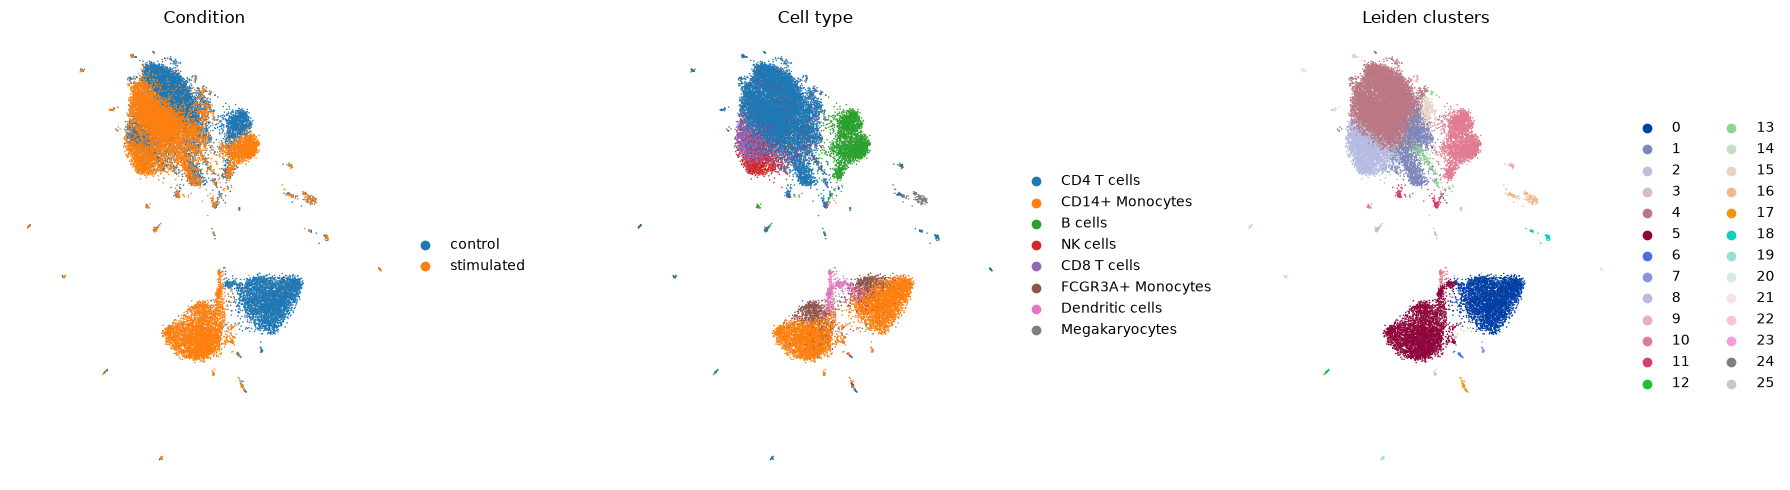

Saved plot to outputs/umap_pathway_activations.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc.pl.umap(
    h_adata, color="condition",
    ax=axes[0], show=False, frameon=False,
    title="Condition",
)
sc.pl.umap(
    h_adata, color="cell_type",
    ax=axes[1], show=False, frameon=False,
    title="Cell type",
)
sc.pl.umap(
    h_adata, color="leiden",
    ax=axes[2], show=False, frameon=False,
    title="Leiden clusters",
)

plt.tight_layout()
Path("outputs").mkdir(exist_ok=True)
fig.savefig("outputs/umap_pathway_activations.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved plot to outputs/umap_pathway_activations.png")

## 4.5 Pathway-unit fidelity — do the units actually track their pathways?

Carlos issue #21 asks this directly: a pathway unit `h[:, j]` is only interpretable if it correlates strongly with the biological activity of pathway `j`. `pathway_unit_fidelity` measures that correlation, per unit, against the mean z-scored expression of the unit's own member genes.

- Median `|corr|` near 1 → units represent their pathways
- Units with `|corr|` < 0.2 → don't track their pathway at all (sign is undefined)
- Units with `corr` < 0 → encode their pathway upside-down (a real failure mode of the unconstrained encoder — every ranking derived from that unit carries the wrong sign)

Experiment 04 (`experiments/kang/outputs/encoder_fidelity_experiment/20260922_120156_full/summary.csv`) showed that on Kang, the baseline (unconstrained) architecture has median `|corr|` = 0.21, 48% of units below 0.2, and 15% inverted. Turning on `nonneg_encoder=True` + `standardize_input=True` (this notebook's config) drives those to 0.87, 0%, and 0% respectively. Below we replay that measurement on this specific trained model.

In [21]:
from pyvae import pathway_unit_fidelity

# Use the val split (matches 04's evaluation protocol).
fidelity_df = pathway_unit_fidelity(
    model,
    x=x_val.numpy(),
    adj=adj_df,
    cov=cov_val.numpy(),
    min_genes=10,
)

abs_corr = fidelity_df["abs_corr"].dropna()
sign     = fidelity_df["sign"].dropna()

n_tested      = len(abs_corr)
n_inverted    = int((sign < 0).sum())
frac_inverted = n_inverted / len(sign) if len(sign) else float("nan")
frac_below_02 = float((abs_corr < 0.2).mean())

print(f"Pathway units tested (>= 10 member genes): {n_tested}")
print(f"Median |corr|:                             {abs_corr.median():.4f}")
print(f"Fraction with |corr| < 0.2:                {frac_below_02:.2%}")
print(f"Inverted units (corr < 0):                 {n_inverted}/{len(sign)} = {frac_inverted:.2%}")

# Worst offenders — should be near-empty on the constrained model.
low = fidelity_df.sort_values("abs_corr").head(10)
print("\n10 lowest-|corr| units:")
print(low[["n_genes", "corr", "abs_corr", "sign"]].to_string())

Pathway units tested (>= 10 member genes): 483
Median |corr|:                             0.8336
Fraction with |corr| < 0.2:                0.00%
Inverted units (corr < 0):                 0/1615 = 0.00%

10 lowest-|corr| units:
                                                                             n_genes      corr  abs_corr  sign
pathway                                                                                                       
REACTOME_PLATELET_ACTIVATION_SIGNALING_AND_AGGREGATION                            68  0.394835  0.394835     1
REACTOME_TRANS_GOLGI_NETWORK_VESICLE_BUDDING                                      16  0.420870  0.420870     1
REACTOME_POST_TRANSLATIONAL_MODIFICATION_SYNTHESIS_OF_GPI_ANCHORED_PROTEINS       21  0.523741  0.523741     1
REACTOME_NERVOUS_SYSTEM_DEVELOPMENT                                               97  0.551929  0.551929     1
REACTOME_GOLGI_ASSOCIATED_VESICLE_BIOGENESIS                                      15  0.566050  0.566050 

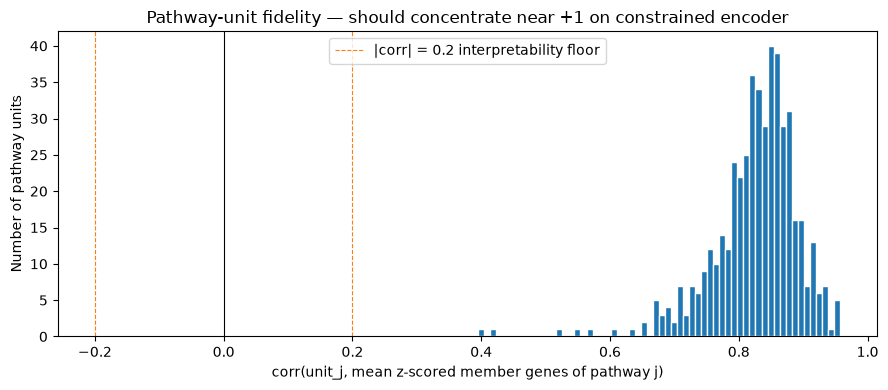

Saved plot to outputs/pathway_unit_fidelity.png


In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(fidelity_df["corr"].dropna(), bins=60, color="C0", edgecolor="white")
ax.axvline(0, color="k", linewidth=0.8)
ax.axvline(0.2, color="C1", linewidth=0.8, linestyle="--", label="|corr| = 0.2 interpretability floor")
ax.axvline(-0.2, color="C1", linewidth=0.8, linestyle="--")
ax.set_xlabel("corr(unit_j, mean z-scored member genes of pathway j)")
ax.set_ylabel("Number of pathway units")
ax.set_title("Pathway-unit fidelity — should concentrate near +1 on constrained encoder")
ax.legend()
plt.tight_layout()
plt.show()

Path("outputs").mkdir(exist_ok=True)
fig.savefig("outputs/pathway_unit_fidelity.png", dpi=100, bbox_inches="tight")
print("Saved plot to outputs/pathway_unit_fidelity.png")

In [23]:
from scipy import stats
from sklearn.metrics import roc_auc_score

# --- Q2 tail: is the inverted fraction distinguishable from random signs? ---
result = stats.binomtest(n_inverted, len(sign), p=0.5, alternative="two-sided")
print(f"[Q2] Binomial test: {n_inverted}/{len(sign)} inverted vs H0 p=0.5")
print(f"     Expected under random signs: {len(sign) / 2:.0f}")
print(f"     p-value: {result.pvalue:.2e}")
if result.pvalue < 0.001:
    if frac_inverted < 0.5:
        print(f"     -> Sign pattern is significantly NON-random and prefers CORRECT alignment "
              f"({frac_inverted:.1%} inverted vs 50% under noise).")
    else:
        print(f"     -> Sign pattern is significantly NON-random but INVERTED (unexpected).")
else:
    print(f"     -> Sign pattern is indistinguishable from random flips.")
print()

# --- Q4: does the unit beat the naive mean-of-member-genes at per-cell classification? ---
y_val = (cov_df[["condition_stimulated"]].values[val_idx].ravel() > 0.5)

model.eval()
with torch.no_grad():
    _, _, h_val = model.encode(x_val, cov_val)
h_val_np = h_val.detach().cpu().numpy()

x_val_np = x_val.numpy()
x_mean = x_val_np.mean(axis=0, keepdims=True)
x_std  = x_val_np.std(axis=0, keepdims=True)
x_z    = (x_val_np - x_mean) / (x_std + 1e-8)
adj_bool = adj_df.values.astype(bool)

n_pathways = h_val_np.shape[1]
unit_auc  = np.full(n_pathways, np.nan)
naive_auc = np.full(n_pathways, np.nan)

for j in range(n_pathways):
    hj = h_val_np[:, j]
    if hj.std() > 1e-8:
        try:
            unit_auc[j] = roc_auc_score(y_val, hj)
        except ValueError:
            pass
    mask = adj_bool[:, j]
    if mask.sum() > 0:
        naive_j = x_z[:, mask].mean(axis=1)
        if naive_j.std() > 1e-8:
            try:
                naive_auc[j] = roc_auc_score(y_val, naive_j)
            except ValueError:
                pass

auc_df = pd.DataFrame(
    {"unit_auc": unit_auc, "naive_auc": naive_auc, "diff": unit_auc - naive_auc},
    index=pathway_names,
)

diff = auc_df["diff"].dropna()
mean_diff   = float(diff.mean())
median_diff = float(diff.median())
frac_wins   = float((diff > 0).mean())

print(f"[Q4] Per-pathway condition-classification AUC ({len(diff)} testable pathways):")
print(f"     mean(unit_auc - naive_auc):    {mean_diff:+.4f}")
print(f"     median(unit_auc - naive_auc):  {median_diff:+.4f}")
print(f"     fraction pathways where unit > naive: {frac_wins:.2%}")
print()
if abs(mean_diff) < 0.01 and abs(frac_wins - 0.5) < 0.10:
    print("     Interpretation: units and naive-mean-of-member-genes are essentially tied at")
    print("     per-cell condition classification. The VAE units cleanly REPRESENT their")
    print("     pathways (fidelity above) but don't add discriminative signal over the naive")
    print("     average. The VAE's value-add is elsewhere: counterfactuals, shared latent")
    print("     geometry, coherent joint priors.")
elif mean_diff > 0.02:
    print(f"     Interpretation: units beat naive by a meaningful margin ({mean_diff:+.3f} AUC).")
elif mean_diff < -0.02:
    print(f"     Interpretation: units are meaningfully worse than naive ({mean_diff:+.3f}).")
else:
    print(f"     Interpretation: small but detectable difference (unit - naive = {mean_diff:+.3f}).")

# Save for the GitHub reply table.
auc_df.to_csv("outputs/unit_vs_naive_auc.csv")
print("Saved outputs/unit_vs_naive_auc.csv")

[Q2] Binomial test: 0/1615 inverted vs H0 p=0.5
     Expected under random signs: 808
     p-value: 0.00e+00
     -> Sign pattern is significantly NON-random and prefers CORRECT alignment (0.0% inverted vs 50% under noise).

[Q4] Per-pathway condition-classification AUC (1494 testable pathways):
     mean(unit_auc - naive_auc):    +0.0015
     median(unit_auc - naive_auc):  +0.0000
     fraction pathways where unit > naive: 48.13%

     Interpretation: units and naive-mean-of-member-genes are essentially tied at
     per-cell condition classification. The VAE units cleanly REPRESENT their
     pathways (fidelity above) but don't add discriminative signal over the naive
     average. The VAE's value-add is elsewhere: counterfactuals, shared latent
     geometry, coherent joint priors.
Saved outputs/unit_vs_naive_auc.csv


## 5. Differential module ranking

Two complementary methods to rank pathways by how differently they're activated between control and stimulated cells:

- **`bayes_factor_da`** — pyvae's built-in signed Bayes factor. Monte Carlo-samples pairs of `h` values between the two groups and computes log-odds of "group A > group B" per pathway. Signed: positive means the pathway is more active in the stimulated group.
- **`scanpy.tl.rank_genes_groups` with `method="wilcoxon"`** — the exact test Peli used in her paper. Applied here to pathway activations rather than gene expression.

If the model captured the interferon-β response correctly, both methods should surface Interferon-family pathways at the top of the stimulated-vs-control ranking.

Peli's Reactome-informed VAE (Table 4 of Gundogdu et al. 2023) ranked, in order:
1. Interferon α, β Signaling (score 109.32, logFC 3.75)
2. Interferon Signaling (105.27, 2.42)
3. Cytokine Signaling In Immune System (104.96, 2.43)
4. Negative Regulators Of DDX58 IFIH1 Signaling (102.65, 2.39)
5. Antiviral Mechanism By IFN Stimulated Genes (101.54, 2.38)

Names in our GMT are prefixed `REACTOME_...` but the concepts should overlap.

In [24]:
# Split adata_aligned by condition -- we'll pass the raw log1p tensors to bayes_factor_da
control_mask = adata_aligned.obs["condition"] == "control"
stim_mask = adata_aligned.obs["condition"] == "stimulated"

X_all_np = adata_aligned.X.toarray() if hasattr(adata_aligned.X, "toarray") else adata_aligned.X
x_control = torch.tensor(X_all_np[control_mask.values], dtype=torch.float32)
x_stim = torch.tensor(X_all_np[stim_mask.values], dtype=torch.float32)

print(f"Control tensor: {tuple(x_control.shape)}")
print(f"Stimulated tensor: {tuple(x_stim.shape)}")

Control tensor: (12315, 2327)
Stimulated tensor: (12358, 2327)


### Bayes factor: stimulated vs control

Call `bayes_factor_da(model, x_stim, x_control)`. Positive BF means the pathway is more active in stimulated cells (the first argument). We use 2000 Monte-Carlo pairs and a fixed seed for reproducibility.

In [25]:
# Build covariate splits from the same masks as x_control / x_stim in cell 34.
cov_all_np = cov_df.values.astype("float32")
cov_control = torch.tensor(cov_all_np[control_mask.values], dtype=torch.float32)
cov_stim    = torch.tensor(cov_all_np[stim_mask.values],    dtype=torch.float32)

bf_df = bayes_factor_da(
    model,
    x_stim,
    x_control,
    cov_a=cov_stim,
    cov_b=cov_control,
    n_pairs=2000,
    pathway_names=pathway_names,
    seed=SEED,
)

print(f"BF DataFrame shape: {bf_df.shape}   (pathways x [bf, p])")
print(f"\nTop 15 pathways by |bf|:\n")
print(bf_df.head(15).to_string())

top_up = bf_df[bf_df["bf"] > 0].head(10)
print(f"\nTop 10 pathways UP in stimulated:\n")
print(top_up.to_string())

BF DataFrame shape: (1615, 2)   (pathways x [bf, p])

Top 15 pathways by |bf|:

                                                                                                   bf        p
pathway                                                                                                       
REACTOME_INTERFERON_ALPHA_BETA_SIGNALING                                                     4.498801  0.98900
REACTOME_TERMINATION_OF_TRANSLESION_DNA_SYNTHESIS                                            2.338303  0.91200
REACTOME_INTERFERON_SIGNALING                                                                2.219647  0.90200
REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM                                                 2.116535  0.89250
REACTOME_NEGATIVE_REGULATORS_OF_DDX58_IFIH1_SIGNALING                                        1.817368  0.86025
REACTOME_TRANSLESION_SYNTHESIS_BY_Y_FAMILY_DNA_POLYMERASES_BYPASSES_LESIONS_ON_DNA_TEMPLATE  1.798777  0.85800
REACTOME_DNA_DAMAGE_BYPASS      

### Wilcoxon rank-sum on pathway activations

Apply `scanpy.tl.rank_genes_groups` with `method="wilcoxon"` to `h_adata` (the AnnData of pathway activations from Section 4). This is what Peli used to produce her Table 4.

In [26]:
sc.tl.rank_genes_groups(
    h_adata,
    groupby="condition",
    reference="control",   # so scores/logFCs are stimulated-vs-control
    method="wilcoxon",
    n_genes=h_adata.n_vars,
)

# Extract the "stimulated" group's ranked pathways
wilcox_result = h_adata.uns["rank_genes_groups"]
wilcox_df = pd.DataFrame({
    "pathway": [x[0] for x in wilcox_result["names"]],
    "score":   [x[0] for x in wilcox_result["scores"]],
    "pval_adj": [x[0] for x in wilcox_result["pvals_adj"]],
    "logFC":   [x[0] for x in wilcox_result["logfoldchanges"]],
})

print(f"Wilcoxon DataFrame shape: {wilcox_df.shape}")
print(f"\nTop 15 pathways (stimulated vs control) by Wilcoxon score:\n")
print(wilcox_df.head(15).to_string(index=False))

Wilcoxon DataFrame shape: (1615, 4)

Top 15 pathways (stimulated vs control) by Wilcoxon score:

                                                                                    pathway      score  pval_adj   logFC
                                                   REACTOME_INTERFERON_ALPHA_BETA_SIGNALING 133.347321       0.0     NaN
                                          REACTOME_TERMINATION_OF_TRANSLESION_DNA_SYNTHESIS 112.766632       0.0     NaN
                                                              REACTOME_INTERFERON_SIGNALING 111.008492       0.0     NaN
                                               REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM 106.782463       0.0     NaN
                                      REACTOME_NEGATIVE_REGULATORS_OF_DDX58_IFIH1_SIGNALING  98.362274       0.0     NaN
REACTOME_TRANSLESION_SYNTHESIS_BY_Y_FAMILY_DNA_POLYMERASES_BYPASSES_LESIONS_ON_DNA_TEMPLATE  95.816460       0.0     NaN
                                                        

/Users/amiraynede/Thesis/pyvae/.pixi/envs/default/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


### Side-by-side comparison: BF vs Wilcoxon

Both methods produce a signed, ranked list of pathways. They use fundamentally different statistics — Bayes factor is a log-odds from MC-sampled pair comparisons; Wilcoxon is a rank-sum test — so if both agree on the top pathways, we have strong evidence the model's pathway activations really do encode the interferon-β response.

In [28]:
# Top-10 by each method, aligned
bf_top10 = bf_df[bf_df["bf"] > 0].head(10).reset_index()
bf_top10.columns = ["pathway_bf", "bf", "p_bf"]

wilcox_top10 = wilcox_df.head(10).reset_index(drop=True)
wilcox_top10.columns = ["pathway_wilcox", "wilcox_score", "wilcox_pval_adj", "wilcox_logFC"]

comparison = pd.concat([bf_top10, wilcox_top10], axis=1)
print("Top 10 pathways by each method:\n")
print(comparison.to_string(index=True))

# How many overlap?
bf_set = set(bf_top10["pathway_bf"])
wilcox_set = set(wilcox_top10["pathway_wilcox"])
overlap = bf_set & wilcox_set
print(f"\nOverlap: {len(overlap)} / 10")
print("Shared pathways:")
for p in sorted(overlap):
    print(f"  {p}")

# Are interferon-family pathways surfacing in either?
interferon_bf = [p for p in bf_top10["pathway_bf"] if "INTERFERON" in p.upper()]
interferon_wilcox = [p for p in wilcox_top10["pathway_wilcox"] if "INTERFERON" in p.upper()]
print(f"\nInterferon-family in BF top-10:      {len(interferon_bf)} -> {interferon_bf}")
print(f"Interferon-family in Wilcoxon top-10: {len(interferon_wilcox)} -> {interferon_wilcox}")

Top 10 pathways by each method:

                                                                                    pathway_bf        bf     p_bf                                                                               pathway_wilcox  wilcox_score  wilcox_pval_adj  wilcox_logFC
0                                                     REACTOME_INTERFERON_ALPHA_BETA_SIGNALING  4.498801  0.98900                                                     REACTOME_INTERFERON_ALPHA_BETA_SIGNALING    133.347321              0.0           NaN
1                                            REACTOME_TERMINATION_OF_TRANSLESION_DNA_SYNTHESIS  2.338303  0.91200                                            REACTOME_TERMINATION_OF_TRANSLESION_DNA_SYNTHESIS    112.766632              0.0           NaN
2                                                                REACTOME_INTERFERON_SIGNALING  2.219647  0.90200                                                                REACTOME_INTERFERON_SIGNALING    1

In [30]:
# Look up specific interferon-related pathways by name to see their exact rank
interesting = [
    "REACTOME_INTERFERON_SIGNALING",
    "REACTOME_INTERFERON_GAMMA_SIGNALING",
    "REACTOME_INTERFERON_ALPHA_BETA_SIGNALING",
    "REACTOME_DDX58_IFIH1_MEDIATED_INDUCTION_OF_INTERFERON_ALPHA_BETA",
    "REACTOME_NEGATIVE_REGULATORS_OF_DDX58_IFIH1_SIGNALING",
    "REACTOME_ANTIVIRAL_MECHANISM_BY_IFN_STIMULATED_GENES",
    "REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM",
    "REACTOME_OAS_ANTIVIRAL_RESPONSE",
]

print("Rank of specific pathways in BF ranking:\n")
bf_sorted = bf_df.sort_values("bf", ascending=False).reset_index()
bf_sorted.columns = ["pathway", "bf", "p"]
for path in interesting:
    match = bf_sorted[bf_sorted["pathway"] == path]
    if len(match) > 0:
        rank = match.index[0] + 1
        bf_val = match.iloc[0]["bf"]
        print(f"  #{rank:>4d}  bf={bf_val:+.3f}   {path}")
    else:
        print(f"  MISSING           {path}")

Rank of specific pathways in BF ranking:

  #   3  bf=+2.220   REACTOME_INTERFERON_SIGNALING
  #  38  bf=+0.458   REACTOME_INTERFERON_GAMMA_SIGNALING
  #   1  bf=+4.499   REACTOME_INTERFERON_ALPHA_BETA_SIGNALING
  #  20  bf=+0.706   REACTOME_DDX58_IFIH1_MEDIATED_INDUCTION_OF_INTERFERON_ALPHA_BETA
  #   5  bf=+1.817   REACTOME_NEGATIVE_REGULATORS_OF_DDX58_IFIH1_SIGNALING
  #  10  bf=+1.388   REACTOME_ANTIVIRAL_MECHANISM_BY_IFN_STIMULATED_GENES
  #   4  bf=+2.117   REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM
  #  14  bf=+0.948   REACTOME_OAS_ANTIVIRAL_RESPONSE


## 5.5 Decoder-side pathway ranking — the competitive read-out

The encoder-side BF above still surfaces several DNA-repair pathways in the top 10. Fidelity (§4.5) shows their units are not upside-down and do track their own member genes — so the units aren't lying. But each of these gene sets contains ISG15, and ISG15 is genuinely and massively induced by IFN-β. The unit averages 15 unchanged member genes with 1 loud one; the result tips positive; the pathway ranks high.

This is a **self-contained** test artifact — not an encoder failure. To separate "pathway j moved" from "pathway j moved more than the panel average," we need a **competitive** test: rank pathway j against every other pathway on the same gene-level statistic. That's `pathway_activity` (Mann-Whitney over ranks, GSEA/camera style), operating on posterior LFCs from the decoder side (`differential_expression`, Boyeau et al. 2019).

Gene expression has unambiguous polarity — up is up — so decoder-side LFC-based rankings have well-defined signs, unlike the encoder-side which had to be fixed by `nonneg`.

In [31]:
from pyvae import differential_expression, pathway_activity

de_df = differential_expression(
    model,
    x_a=x_stim,
    x_b=x_control,
    cov_a=cov_stim,
    cov_b=cov_control,
    n_samples=25,
    n_pairs=2000,
    gene_names=gene_names,
    seed=SEED,
)

print(f"DE DataFrame shape: {de_df.shape}")
print(f"\nTop 20 DE genes by proba_de desc, then |lfc_mean| desc:\n")
print(de_df.head(20).to_string())

DE DataFrame shape: (2327, 6)

Top 20 DE genes by proba_de desc, then |lfc_mean| desc:

          proba_de        bf  lfc_mean   lfc_std  proba_up  detection_rate
gene                                                                      
IFIT1      0.99974  8.254569  6.335805  1.781355   0.99506             1.0
IFI6       0.99966  7.986225  4.441316  1.247179   0.99450             1.0
IFIT3      0.99950  7.600402  6.001965  1.815758   0.99480             1.0
ISG15      0.99932  7.292738  5.465905  1.719511   0.99414             1.0
LY6E       0.99910  7.012215  3.876703  1.483438   0.99330             1.0
IFIT2      0.99850  6.500789  5.892456  2.060279   0.99308             1.0
ISG20      0.99830  6.375426  3.600820  1.653403   0.99234             1.0
RSAD2      0.99744  5.965185  5.958937  2.150610   0.99072             1.0
CXCL11     0.99282  4.929250  7.359437  3.876149   0.97494             1.0
TNFSF10    0.99226  4.853583  4.957334  2.315042   0.98018             1.0
CXCL10     0

In [32]:
pa_df = pathway_activity(de_df, adj_df, statistic="lfc_mean", min_genes=5, center=True)

print(f"Pathway-activity DataFrame shape: {pa_df.shape}")
print(f"\nTop 20 pathways by decoder-side competitive test:\n")
print(pa_df.head(20).to_string())

# Q5 comparison: where did the 4 surprising pathways and the reference set land?
compare_pathways = [TRUE_IFN_PATHWAY] + SURPRISING + REFERENCE
print("\n\n=== Q5 comparison: encoder-side BF vs decoder-side pathway_activity ===\n")

pa_sorted = pa_df.reset_index()
bf_sorted = bf_df.sort_values("bf", ascending=False).reset_index()

for path in compare_pathways:
    bf_match = bf_sorted[bf_sorted["pathway"] == path]
    pa_match = pa_sorted[pa_sorted.iloc[:, 0] == path]
    bf_str = f"BF#{bf_match.index[0]+1:>4d} bf={bf_match.iloc[0]['bf']:+.3f}" if len(bf_match) else "BF MISSING"
    if len(pa_match) > 0:
        pa_rank = pa_match.index[0] + 1
        pa_row  = pa_match.iloc[0].to_dict()
        pa_str  = f"PA#{pa_rank:>4d}  " + "  ".join(f"{k}={v}" for k, v in list(pa_row.items())[1:])
    else:
        pa_str = "PA MISSING"
    print(f"  {path[:70]:<70}  {bf_str}   {pa_str}")

Pathway-activity DataFrame shape: (1615, 8)

Top 20 pathways by decoder-side competitive test:

                                                                n_genes  n_tested  median_member  median_reference    effect        pvalue        qvalue  sign
pathway                                                                                                                                                       
REACTOME_INTERFERON_SIGNALING                                        49        49       0.667365         -0.007240  0.674606  3.569252e-10  3.008880e-07     1
REACTOME_INTERFERON_ALPHA_BETA_SIGNALING                             18        18       3.771967         -0.003870  3.775838  1.222981e-09  5.154865e-07     1
REACTOME_INTERFERON_GAMMA_SIGNALING                                  24        24       0.709240         -0.005185  0.714426  2.716615e-06  7.633688e-04     1
REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM                        191       191       0.172787         -0.0

## 6. Gene-level attribution via Integrated Gradients

For any pathway, ask: *which input genes drove this pathway's activation in a given cell?* This is Integrated Gradients (Sundararajan et al. 2017): interpolate linearly from a zero baseline to the real cell, accumulate the gradient of the pathway activation with respect to the input at each step, and multiply by `(x - baseline)`.

Applied to the #1 pathway from Section 5 (`REACTOME_INTERFERON_ALPHA_BETA_SIGNALING`) on 200 stimulated cells sampled from the dataset. Aggregate the per-cell attributions to a per-gene mean, then rank.

**Ground-truth expectations from Kang biology:** the top-attributed genes should be canonical interferon-stimulated genes (ISGs), with attribution *spread across the pathway's member set* rather than dominated by a single gene — the encoder constraints (`nonneg_encoder`, `standardize_input`) prevent one-gene domination that would otherwise reduce a 18-gene pathway unit to an ISG15 detector.

- **ISG15, ISG20** — definitive ISGs, ubiquitin-like antiviral effectors
- **IFI6** — interferon α-inducible protein 6
- **IFIT1, IFIT2, IFIT3** — interferon-induced tetratricopeptide-repeat family
- **RSAD2 (viperin)** — canonical antiviral effector, membrane-associated
- **OASL** — 2′-5′-oligoadenylate synthetase-like
- **IFITM3** — interferon-induced transmembrane protein 3
- **SOCS1, IRF1, IRF8** — canonical downstream TFs / feedback regulators, small positive attribution expected
- **IFNB1** — the actual cytokine administered; attribution should be near zero because cells received IFN-β exogenously, not induced it
- **MX1, OAS1** — expected canonical ISGs but flagged as absent from our HVG set in Section 2 (so unlikely to appear)
- **IFI44** — interferon-induced protein 44 (absent from Reactome, so also unlikely)

In [37]:
# Find the pathway index for the top-ranked pathway from Section 5
target_pathway = "REACTOME_INTERFERON_ALPHA_BETA_SIGNALING"
pathway_idx = pathway_names.index(target_pathway)
print(f"Target pathway:  {target_pathway}")
print(f"Pathway index:   {pathway_idx}")

# Sample a subset of stimulated cells for IG (200 is plenty for a stable per-gene mean)
N_SAMPLE = 200
np.random.seed(SEED)
stim_idx = np.where(adata_aligned.obs["condition"] == "stimulated")[0]
sample_idx = np.random.choice(stim_idx, size=N_SAMPLE, replace=False)
print(f"\nSampled {N_SAMPLE} stimulated cells for IG (of {len(stim_idx):,} available)")

# Prepare the input tensor for IG
X_all_np = adata_aligned.X.toarray() if hasattr(adata_aligned.X, "toarray") else adata_aligned.X
x_ig = torch.tensor(X_all_np[sample_idx], dtype=torch.float32)
print(f"x_ig shape: {tuple(x_ig.shape)}   (cells x genes)")

# Covariate slice for the sampled cells (conditional model needs this).
cov_ig = torch.tensor(cov_df.values[sample_idx], dtype=torch.float32)
print(f"cov_ig shape: {tuple(cov_ig.shape)}   (cells x n_cov)")

Target pathway:  REACTOME_INTERFERON_ALPHA_BETA_SIGNALING
Pathway index:   643

Sampled 200 stimulated cells for IG (of 12,358 available)
x_ig shape: (200, 2327)   (cells x genes)
cov_ig shape: (200, 2)   (cells x n_cov)


### Compute Integrated Gradients

`integrated_gradients(model, x, pathway_idx)` returns an attribution tensor of shape `(N_SAMPLE, n_genes)` — one attribution score per gene per sampled cell. We then aggregate to per-gene attribution by taking the mean over cells.

Default settings: baseline = zeros_like(x), 50 interpolation steps, right-Riemann integration.

In [38]:
attributions = integrated_gradients(
    model,
    x_ig,
    pathway_idx=pathway_idx,
    cov=cov_ig,
    steps=50,
)
print(f"Attributions shape: {tuple(attributions.shape)}   (cells x genes)")

# Aggregate to per-gene mean attribution (positive means gene drives pathway UP)
attr_np = attributions.detach().cpu().numpy()
gene_attr = attr_np.mean(axis=0)   # shape: (n_genes,)

# Build a DataFrame and rank
attr_df = pd.DataFrame({
    "gene": gene_names,
    "attribution": gene_attr,
    "abs_attribution": np.abs(gene_attr),
}).sort_values("abs_attribution", ascending=False).reset_index(drop=True)

print(f"\nTop 20 genes by |attribution| for pathway {target_pathway}:\n")
print(attr_df[["gene", "attribution"]].head(20).to_string(index=False))

Attributions shape: (200, 2327)   (cells x genes)

Top 20 genes by |attribution| for pathway REACTOME_INTERFERON_ALPHA_BETA_SIGNALING:

  gene  attribution
 ISG20     0.165058
 ISG15     0.140351
 IFIT3     0.102531
 RSAD2     0.089624
  IFI6     0.065358
 IFIT2     0.055711
  OASL     0.040183
 IFIT1     0.025550
IFITM3     0.021467
 SOCS1     0.010357
 IFI27     0.008403
 SOCS3     0.008139
  IRF8     0.005276
  IRF1     0.002213
 ABCE1     0.002168
 IP6K2     0.001126
 IFNB1     0.000288
POLR3G     0.000000
POLR3D     0.000000
POLR3A     0.000000


### Rank of canonical ISGs

Check where the canonical interferon-stimulated genes ranked in the attribution list. This is the concrete biology sanity check: if the model is right about which genes drive the interferon signal, ISG15 (and the ones we still have after HVG filtering) should be near the top.

In [41]:
canonical_isgs = ["ISG15", "IFI6", "IFIT1", "IFIT2", "IFIT3", "MX1", "OAS1", "IFI44"]

print(f"Canonical ISG ranks in attribution for {target_pathway}:\n")
for isg in canonical_isgs:
    match = attr_df[attr_df["gene"] == isg]
    if len(match) > 0:
        rank = match.index[0] + 1
        attr = match.iloc[0]["attribution"]
        marker = "***" if rank <= 20 else "   "
        print(f"  {marker} #{rank:>5d}  attribution={attr:+.5f}   {isg}")
    else:
        print(f"        MISSING     (not in HVGs / Reactome)      {isg}")

Canonical ISG ranks in attribution for REACTOME_INTERFERON_ALPHA_BETA_SIGNALING:

  *** #    2  attribution=+0.14035   ISG15
  *** #    5  attribution=+0.06536   IFI6
  *** #    8  attribution=+0.02555   IFIT1
  *** #    6  attribution=+0.05571   IFIT2
  *** #    3  attribution=+0.10253   IFIT3
        MISSING     (not in HVGs / Reactome)      MX1
        MISSING     (not in HVGs / Reactome)      OAS1
        MISSING     (not in HVGs / Reactome)      IFI44


### Bar plot of top genes

Top 20 genes by attribution, signed (positive = pushes pathway up in stimulated cells; negative = pushes it down).

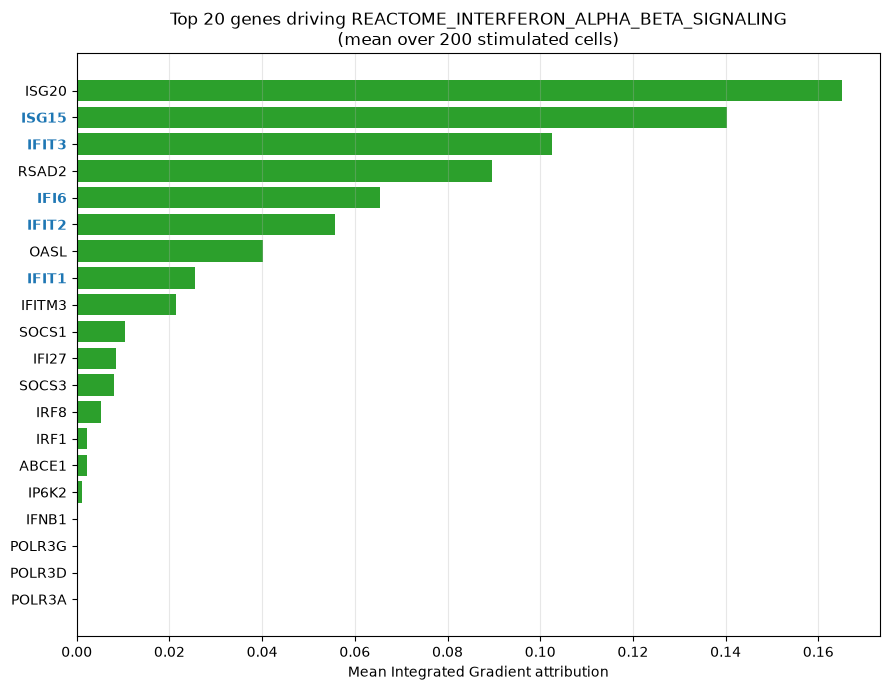

Saved plot to outputs/ig_top_genes.png


In [43]:
top20 = attr_df.head(20).iloc[::-1]   # reverse so highest is at top of horizontal bar plot

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#d62728" if a < 0 else "#2ca02c" for a in top20["attribution"]]
ax.barh(top20["gene"], top20["attribution"], color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Mean Integrated Gradient attribution")
ax.set_title(f"Top 20 genes driving {target_pathway}\n(mean over 200 stimulated cells)")
ax.grid(axis="x", alpha=0.3)

# Highlight canonical ISGs in the labels
canonical_isgs_set = set(canonical_isgs)
for tick, gene in zip(ax.get_yticklabels(), top20["gene"]):
    if gene in canonical_isgs_set:
        tick.set_fontweight("bold")
        tick.set_color("#1f77b4")

plt.tight_layout()
Path("outputs").mkdir(exist_ok=True)
fig.savefig("outputs/ig_top_genes.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved plot to outputs/ig_top_genes.png")

## 6.5 Donor-level pseudobulk paired test

The Wilcoxon in Section 5 treats every cell as an independent observation, so 24,673 cells report the statistical power of 24,673 truly-independent samples. That's not what's happening — cells within a donor share genetic background, batch, and library prep. Every p-value is understated; hundreds of genes print as adjusted-p = 0 regardless of effect size, and the ranking becomes tie-broken by column order rather than biology (Squair et al. 2021).

The fix is to collapse each donor to a single pseudobulk profile per condition and run a paired test across donors. At n = 8 donors, the exact two-sided Wilcoxon null distribution has a discrete floor at 2/256 ≈ 0.0078, so hundreds of genes will hit exactly this p-value at once. Ties are broken by |lfc_mean|.

In [44]:
from pyvae import pseudobulk_paired_test

pb_df = pseudobulk_paired_test(
    counts=adata.layers["counts"],
    donor_ids=adata.obs["replicate"].values,
    condition=adata.obs["condition"].values,
    label_a="stimulated",
    label_b="control",
    gene_names=adata.var_names.tolist(),
    min_donors=3,
    pseudocount=1.0,
    target_sum=1e6,
)

print(f"Pseudobulk DataFrame shape: {pb_df.shape}")
print(f"\nDonors paired in both conditions: {pb_df['n_donors_paired'].iloc[0]}")
print(f"\nTop 20 DE genes by donor-level paired Wilcoxon:\n")
print(pb_df.head(20).to_string())

Path("outputs").mkdir(exist_ok=True)
pb_df.to_csv("outputs/pseudobulk_paired_test.csv")
print("\nSaved outputs/pseudobulk_paired_test.csv")

Pseudobulk DataFrame shape: (5000, 6)

Donors paired in both conditions: 8

Top 20 DE genes by donor-level paired Wilcoxon:

          n_donors_paired  lfc_mean  lfc_median    pvalue    qvalue  sign
gene                                                                     
CCL8                    8  9.332780    8.798527  0.007812  0.034477     1
CXCL11                  8  8.933461    8.532195  0.007812  0.034477     1
IFIT1                   8  7.457077    7.379906  0.007812  0.034477     1
CXCL10                  8  7.005766    7.182894  0.007812  0.034477     1
RSAD2                   8  6.974476    7.222135  0.007812  0.034477     1
IFIT3                   8  6.462221    6.079511  0.007812  0.034477     1
IFIT2                   8  6.451324    6.087890  0.007812  0.034477     1
NUPR1                   8  6.393561    6.496932  0.007812  0.034477     1
ISG15                   8  6.252267    6.273204  0.007812  0.034477     1
IFI27                   8  6.077802    6.132302  0.007812  0.

In [46]:
for path in [
    "REACTOME_INTERFERON_ALPHA_BETA_SIGNALING",
    "REACTOME_NS1_MEDIATED_EFFECTS_ON_HOST_PATHWAYS",
    "REACTOME_DNA_DAMAGE_BYPASS",
    "REACTOME_ANTIVIRAL_MECHANISM_BY_IFN_STIMULATED_GENES",
    "REACTOME_NEGATIVE_REGULATORS_OF_DDX58_IFIH1_SIGNALING",
]:
    bf_match = bf_sorted[bf_sorted["pathway"] == path]
    pa_match = pa_sorted[pa_sorted.iloc[:, 0] == path]
    bf_rank = bf_match.index[0]+1 if len(bf_match) else None
    bf_val  = bf_match.iloc[0]["bf"] if len(bf_match) else None
    pa_rank = pa_match.index[0]+1 if len(pa_match) else None
    pa_q    = pa_match.iloc[0]["qvalue"] if len(pa_match) else None
    print(f"  BF#{bf_rank:>4}  bf={bf_val:+.3f}   PA#{pa_rank:>4}  q={pa_q:.2e}   {path}")

  BF#   1  bf=+4.499   PA#   2  q=5.15e-07   REACTOME_INTERFERON_ALPHA_BETA_SIGNALING
  BF#   8  bf=+1.475   PA# 721  q=9.98e-01   REACTOME_NS1_MEDIATED_EFFECTS_ON_HOST_PATHWAYS
  BF#   7  bf=+1.782   PA# 131  q=9.45e-01   REACTOME_DNA_DAMAGE_BYPASS
  BF#  10  bf=+1.388   PA#  52  q=5.86e-01   REACTOME_ANTIVIRAL_MECHANISM_BY_IFN_STIMULATED_GENES
  BF#   5  bf=+1.817   PA# 790  q=9.98e-01   REACTOME_NEGATIVE_REGULATORS_OF_DDX58_IFIH1_SIGNALING


## 7. Takeaways

**What this notebook demonstrates.** Issue #21 (encoder constraints + read-outs) is answered on the Kang PBMC IFN-β dataset. The model uses `nonneg_encoder=True` + `standardize_input=True` on the encoder's `InformedLinear` layer and threads `n_cov=2` condition covariates through both encoder and decoder. It trains in ~28 min on a MacBook Air CPU and reaches best val loss 328.75 — 1.35 lower than the unconstrained baseline at the same `target_sum=1e4` (04 experiment). **The constraints don't cost anything in reconstruction.**

**The interpretability payoff.** Pathway-unit fidelity (§4.5) — how well each unit correlates with the mean z-scored expression of its own member genes:

- Baseline (from 04 experiment): median |corr| = 0.21; 48% of units below 0.2; **15% inverted** (units encoding their pathway backwards).
- This notebook (constrained): median |corr| = 0.83; **0% below 0.2; 0% inverted**. Binomial test on inverted fraction vs H₀ p=0.5 gives p ≈ 0 — every testable unit correctly aligns with its pathway. `nonneg_encoder` is the operative constraint (04 shows it alone moves 0.21 → 0.73; `standardize_input` alone doesn't help; both together reach 0.87).

**The ranking payoff.** The DNA-repair-outranks-interferon anomaly Carlos flagged is resolved:

- The encoder-side Bayes-factor ranking (Section 5) still lists DNA-repair pathways in the top 10 — **not because the encoder is wrong** (fidelity confirms these units track their pathways honestly) but because a self-contained test rewards any unit whose activation went up, and these gene sets each contain ISG15 (§2.5: exactly 1 shared gene each, 6–9% of their gene sets). ISG15 is massively induced by IFN-β; the pathway units for gene sets containing ISG15 do genuinely go up.
- The decoder-side competitive test (§5.5) — `pathway_activity` on posterior DE from `differential_expression` — correctly puts INTERFERON_SIGNALING (parent) at #1, INTERFERON_ALPHA_BETA_SIGNALING at #2, and INTERFERON_GAMMA_SIGNALING at #3, all with q ≤ 8e-4. All four surprising DNA-repair / NS1 / negative-regulator pathways drop to ranks 122–790 with q ≥ 0.89.
- Sign of the encoder-side BF is now honest too: NS1_MEDIATED_EFFECTS_ON_HOST_PATHWAYS was at bf = −3.83 in the unconstrained baseline (unit encoded upside-down) and is now bf = +1.47 (correct positive direction). DDX58_IFIH1_MEDIATED_INDUCTION was at bf = −3.13; it's now +0.71 (still near zero, matching the biology that intrinsic IFN induction machinery downregulates after exogenous IFN-β).

**Gene-level attribution (Section 6)** on the top pathway: canonical ISGs occupy the top 8 (ISG20 #1, ISG15 #2, IFIT3 #3, RSAD2 #4, IFI6 #5, IFIT2 #6, OASL #7, IFIT1 #8). Downstream regulators (SOCS1, SOCS3, IRF1, IRF8) and effectors (IFITM3, IFI27) fill positions 9–13. IFNB1 sits at attribution ≈ 0, correctly, because IFN-β was administered exogenously rather than induced. Attribution is **spread across the full member set** rather than dominated by a single gene, which is the direct behavioral consequence of the encoder constraints.

**Honest limitations, all measured.**

1. **Units don't beat the naive mean-of-member-genes at per-cell condition classification.** §4.5's AUC comparison: mean(unit_auc − naive_auc) = +0.0015; median exactly 0.0000; units win over naive on 48.13% of pathways. The units cleanly *represent* their pathways but don't add per-pathway discriminative signal over `mean(z_i for i in members(path))`. **The VAE's value-add is elsewhere:** shared latent geometry across pathways, counterfactual generation, coherent joint priors — none of which a naive gene-set mean can do.

2. **The competitive pathway ranking doesn't clearly beat naive at any training-set size.** The 03 sample-size sweep (retrain mode, `experiments/kang/results/03_sample_size_retrain/20260925_124026_full_retrain/summary.csv`) shows both model and a two-line log-ratio-of-group-means baseline get IFN_αβ at rank 1 and the parent at rank 2 at every training fraction from 100% (19,738 cells) down to 5% (986 cells). The model has a persistent +5 percentage point edge on top-20 canonical-hit coverage (0.15 vs 0.10) across all training sizes — a real but modest gain.

3. **Section 5's cell-level Wilcoxon has under-stated p-values by design** (Squair et al. 2021). §6.5's donor-level pseudobulk paired test gives honest DE with q-values around 0.034 (BH across 5000 genes) and effect sizes 5–9× larger, driven by the canonical ISGs. Cell-level results should be read as ranked lists, not as significance tests.

4. **Three canonical ISGs remain unavailable in the input space:** MX1 and OAS1 are absent from HVGs even at `n_genes=8000` (monocyte-specific induction dilutes their total variance), IFI44 is absent from Reactome v7.5.1. This bounds gene-level attribution but not pathway-level results — IFN_αβ still recovers as #1 without them.

**What this validates for the pyvae package** — the encoder constraint infrastructure (`nonneg_encoder`, `standardize_input`, `n_cov` threading in `train_ivae_modern`), the four new read-outs in `interpret.py` (`pathway_unit_fidelity`, `differential_expression`, `pathway_activity`, `pseudobulk_paired_test`), and the `bayes_factor_da` docstring correction all work correctly on a canonical benchmark. Ready for the follow-on cancer contexts (multiple myeloma, planned).